# ECON4002 — Week 5: Consumer Theory I: R Code Snippets

**University of Western Australia**  
*R implementations for utility maximization, MRS, and Marshallian demand*

---

## Key Formulae

Utility maximisation: $\max U(x_1, x_2)$ s.t. $p_1 x_1 + p_2 x_2 = m$. MRS: $\frac{MU_1}{MU_2} = \frac{p_1}{p_2}$

---

> **How to use:** Run each cell in order. Modify the parameters and re-run to explore the economics.

In [ ]:
# ECON4002 Week 5 — R Setup
# Run this cell first to configure options
options(scipen = 6, digits = 4)
cat('Week 5: Consumer Theory I: R Code Snippets — ready!\n')

Week 5: Consumer Theory I: R Code Snippets — ready!


## Indifference Curves

### W5-CS01 — Plot Cobb-Douglas Indifference Curves

> **Note:** x₂ = (U/x₁^α)^(1/(1-α)) derived by solving U = x₁^α x₂^(1-α) for x₂

In [ ]:
plot_IC_CD <- function(alpha = 0.5, u_levels = c(5, 10, 15, 20)) {
  x1 <- seq(0.1, 30, length = 200)
  
  plot(NULL, xlim = c(0, 30), ylim = c(0, 30),
       xlab = expression(x[1]), ylab = expression(x[2]),
       main = paste('Cobb-Douglas IC (α =', alpha, ')'))
  
  colors <- rainbow(length(u_levels))
  for (i in seq_along(u_levels)) {
    u <- u_levels[i]
    # From U = x1^α * x2^(1-α), solve for x2
    x2 <- (u / x1^alpha)^(1/(1-alpha))
    x2[x2 > 30] <- NA
    lines(x1, x2, col = colors[i], lwd = 2)
  }
  legend('topright', legend = paste('U =', u_levels),
         col = colors, lwd = 2)
  grid()
}

plot_IC_CD(alpha = 0.4)

## Mrs

### W5-CS02 — Calculate MRS

> **Note:** MRS = MU₁/MU₂. For CD: MRS = (α/(1-α))(x₂/x₁)

In [ ]:
# Numerical MRS via gradient
MRS_numerical <- function(U_fn, x1, x2, h = 1e-6) {
  MU1 <- (U_fn(x1 + h, x2) - U_fn(x1 - h, x2)) / (2 * h)
  MU2 <- (U_fn(x1, x2 + h) - U_fn(x1, x2 - h)) / (2 * h)
  return(MU1 / MU2)
}

# Analytical MRS for Cobb-Douglas
MRS_CD <- function(x1, x2, alpha = 0.5) {
  (alpha / (1 - alpha)) * (x2 / x1)
}

# Test
U_CD <- function(x1, x2) x1^0.3 * x2^0.7
cat('Numerical MRS:', MRS_numerical(U_CD, 10, 20), '\n')
cat('Analytical MRS:', MRS_CD(10, 20, 0.3), '\n')

## Budget

### W5-CS03 — Plot Budget Constraint

> **Note:** Budget line: p₁x₁ + p₂x₂ = m. Intercepts at m/p₁ and m/p₂.

In [ ]:
plot_budget <- function(p1, p2, m, col = 'black', add = FALSE) {
  x1_max <- m / p1
  x2_max <- m / p2
  
  if (!add) {
    plot(NULL, xlim = c(0, x1_max * 1.1), ylim = c(0, x2_max * 1.1),
         xlab = expression(x[1]), ylab = expression(x[2]),
         main = 'Budget Constraint')
  }
  
  # Budget line
  segments(0, x2_max, x1_max, 0, col = col, lwd = 2)
  
  # Shade feasible region
  polygon(c(0, 0, x1_max), c(0, x2_max, 0),
          col = rgb(0.5, 0.5, 0.5, 0.2), border = NA)
  
  # Label intercepts
  text(x1_max, 0, round(x1_max, 1), pos = 1)
  text(0, x2_max, round(x2_max, 1), pos = 2)
  grid()
}

plot_budget(p1 = 4, p2 = 5, m = 100)

## Demand

### W5-CS04 — Cobb-Douglas Demand Function

> **Note:** x₁ = αm/p₁, x₂ = (1-α)m/p₂. Expenditure shares equal exponents.

In [ ]:
cobb_douglas_demand <- function(p1, p2, m, alpha = 0.5) {
  x1 <- alpha * m / p1
  x2 <- (1 - alpha) * m / p2
  utility <- x1^alpha * x2^(1 - alpha)
  lambda <- alpha * utility / (x1 * p1)  # MU1/p1
  
  return(list(
    x1 = x1,
    x2 = x2,
    utility = utility,
    lambda = lambda,
    expenditure_share_1 = p1 * x1 / m,
    expenditure_share_2 = p2 * x2 / m
  ))
}

# Test
result <- cobb_douglas_demand(p1 = 2, p2 = 3, m = 120, alpha = 0.4)
cat('x1* =', result$x1, '\n')
cat('x2* =', result$x2, '\n')
cat('Utility =', round(result$utility, 3), '\n')
cat('λ =', result$lambda, '\n')
cat('Expenditure shares:', result$expenditure_share_1, ',', result$expenditure_share_2)

### W5-CS06 — Perfect Substitutes Demand

> **Note:** Corner solution: buy whichever good has higher MU per dollar.

In [ ]:
perfect_subs_demand <- function(a, b, p1, p2, m) {
  # U = a*x1 + b*x2
  MU_per_dollar_1 <- a / p1
  MU_per_dollar_2 <- b / p2
  
  if (MU_per_dollar_1 > MU_per_dollar_2) {
    x1 <- m / p1
    x2 <- 0
    corner <- 'x1 only'
  } else if (MU_per_dollar_1 < MU_per_dollar_2) {
    x1 <- 0
    x2 <- m / p2
    corner <- 'x2 only'
  } else {
    x1 <- m / (2 * p1)  # Convention: split
    x2 <- m / (2 * p2)
    corner <- 'indifferent'
  }
  
  utility <- a * x1 + b * x2
  
  return(list(x1 = x1, x2 = x2, utility = utility,
              corner = corner,
              MU_per_dollar = c(MU_per_dollar_1, MU_per_dollar_2)))
}

# Test: U = 3x1 + 4x2
result <- perfect_subs_demand(a = 3, b = 4, p1 = 6, p2 = 10, m = 60)
cat('Solution:', result$corner, '\n')
cat('x1 =', result$x1, ', x2 =', result$x2, '\n')
cat('MU per dollar:', result$MU_per_dollar)

### W5-CS07 — Perfect Complements Demand

> **Note:** Always consume at kink where a·x₁ = b·x₂.

In [ ]:
perfect_comp_demand <- function(a, b, p1, p2, m) {
  # U = min{a*x1, b*x2}
  # At optimum: a*x1 = b*x2 → x2 = (a/b)*x1
  # Budget: p1*x1 + p2*(a/b)*x1 = m
  
  x1 <- m / (p1 + p2 * a / b)
  x2 <- (a / b) * x1
  utility <- a * x1  # = b * x2
  
  return(list(x1 = x1, x2 = x2, utility = utility,
              ratio = paste(a, ':', b)))
}

# Test: U = min{2x1, x2} → consume in ratio 1:2
result <- perfect_comp_demand(a = 2, b = 1, p1 = 4, p2 = 2, m = 40)
cat('x1 =', result$x1, ', x2 =', result$x2, '\n')
cat('Utility =', result$utility, '\n')
cat('Consumption ratio x1:x2 =', result$ratio)

### W5-CS08 — Quasi-Linear Utility

> **Note:** Quasi-linear: zero income effect for good with nonlinear term.

In [ ]:
# U = x1 + v(x2) where v is concave
# Example: U = x1 + 4*sqrt(x2)

quasi_linear_demand <- function(p1, p2, m) {
  # FOC: v'(x2) = p2/p1
  # Here: 2/sqrt(x2) = p2/p1 → x2 = (2*p1/p2)^2
  
  x2 <- (2 * p1 / p2)^2
  
  # Check if interior solution is feasible
  if (p2 * x2 > m) {
    # Corner: spend all on x2
    x2 <- m / p2
    x1 <- 0
  } else {
    x1 <- (m - p2 * x2) / p1
  }
  
  utility <- x1 + 4 * sqrt(x2)
  
  return(list(x1 = x1, x2 = x2, utility = utility))
}

# Test
for (m in c(10, 20, 50)) {
  result <- quasi_linear_demand(p1 = 1, p2 = 4, m = m)
  cat('m =', m, ': x1 =', result$x1, ', x2 =', result$x2, '\n')
}
# Note: x2 stays constant (0.25), all extra income goes to x1

## Visualization

### W5-CS05 — Complete Consumer Choice Diagram

> **Note:** Shows tangency of IC and budget line at optimal bundle.

In [ ]:
plot_consumer_choice <- function(p1, p2, m, alpha = 0.5) {
  # Get optimal bundle
  result <- cobb_douglas_demand(p1, p2, m, alpha)
  x1_star <- result$x1
  x2_star <- result$x2
  u_star <- result$utility
  
  # Plot setup
  x1_max <- m / p1 * 1.2
  x2_max <- m / p2 * 1.2
  
  plot(NULL, xlim = c(0, x1_max), ylim = c(0, x2_max),
       xlab = expression(x[1]), ylab = expression(x[2]),
       main = 'Utility Maximization')
  
  # Budget line
  segments(0, m/p2, m/p1, 0, col = 'blue', lwd = 2)
  
  # Indifference curves
  x1_seq <- seq(0.1, x1_max, length = 200)
  for (u in c(u_star * 0.7, u_star, u_star * 1.3)) {
    x2_seq <- (u / x1_seq^alpha)^(1/(1-alpha))
    x2_seq[x2_seq > x2_max] <- NA
    lines(x1_seq, x2_seq, col = 'red', lwd = ifelse(abs(u - u_star) < 0.01, 2, 1))
  }
  
  # Optimal point
  points(x1_star, x2_star, pch = 19, cex = 1.5, col = 'darkgreen')
  text(x1_star, x2_star, paste0('(', round(x1_star,1), ', ', round(x2_star,1), ')'),
       pos = 4, col = 'darkgreen')
  
  legend('topright', legend = c('Budget', 'IC', 'Optimal'),
         col = c('blue', 'red', 'darkgreen'), lty = c(1, 1, NA),
         pch = c(NA, NA, 19), lwd = 2)
  grid()
}

plot_consumer_choice(p1 = 2, p2 = 3, m = 120, alpha = 0.4)

## Demand Curves

### W5-CS09 — Derive Demand Curve

> **Note:** Demand curve shows x₁ as function of p₁, holding p₂ and m constant.

In [ ]:
plot_demand_curve <- function(p2 = 3, m = 120, alpha = 0.5) {
  p1_range <- seq(0.5, 20, by = 0.5)
  
  # Marshallian demand for x1 as p1 varies
  x1_demand <- alpha * m / p1_range
  
  plot(x1_demand, p1_range, type = 'l', col = 'blue', lwd = 2,
       xlab = expression(x[1]), ylab = expression(p[1]),
       main = 'Marshallian Demand Curve for x₁')
  grid()
  
  # Mark a point
  p1_test <- 4
  x1_test <- alpha * m / p1_test
  points(x1_test, p1_test, pch = 19, col = 'red', cex = 1.5)
  text(x1_test, p1_test, paste0('(', x1_test, ', ', p1_test, ')'), pos = 4)
}

plot_demand_curve(p2 = 3, m = 120, alpha = 0.5)

## Engel

### W5-CS10 — Engel Curves

> **Note:** Engel curve: demand as function of income. Linear for Cobb-Douglas.

In [ ]:
plot_engel_curves <- function(p1 = 2, p2 = 3, alpha = 0.5) {
  m_range <- seq(10, 200, by = 5)
  
  x1_engel <- alpha * m_range / p1
  x2_engel <- (1 - alpha) * m_range / p2
  
  par(mfrow = c(1, 2))
  
  plot(m_range, x1_engel, type = 'l', col = 'blue', lwd = 2,
       xlab = 'Income (m)', ylab = expression(x[1]),
       main = 'Engel Curve for x₁')
  grid()
  
  plot(m_range, x2_engel, type = 'l', col = 'red', lwd = 2,
       xlab = 'Income (m)', ylab = expression(x[2]),
       main = 'Engel Curve for x₂')
  grid()
  
  par(mfrow = c(1, 1))
}

plot_engel_curves()

## Numerical

### W5-CS11 — Numerical Utility Maximization

> **Note:** General numerical solver works for any differentiable utility function.

In [ ]:
library(nloptr)

utility_max_general <- function(U_fn, p1, p2, m) {
  # Objective (negative for maximization)
  eval_f <- function(x) -U_fn(x[1], x[2])
  
  # Budget constraint: p1*x1 + p2*x2 - m = 0
  eval_g_eq <- function(x) p1 * x[1] + p2 * x[2] - m
  eval_jac_g_eq <- function(x) c(p1, p2)
  
  # Solve
  result <- nloptr(
    x0 = c(m / (2 * p1), m / (2 * p2)),
    eval_f = eval_f,
    eval_g_eq = eval_g_eq,
    eval_jac_g_eq = eval_jac_g_eq,
    lb = c(0.001, 0.001),  # Positive consumption
    opts = list(algorithm = 'NLOPT_LD_SLSQP', xtol_rel = 1e-8)
  )
  
  return(list(x1 = result$solution[1], x2 = result$solution[2],
              utility = -result$objective))
}

# Test with CES utility
U_CES <- function(x1, x2) (x1^0.5 + x2^0.5)^2
result <- utility_max_general(U_CES, p1 = 2, p2 = 3, m = 100)
cat('CES demand: x1 =', round(result$x1, 2), ', x2 =', round(result$x2, 2))

## Elasticity

### W5-CS12 — Price Elasticity of Demand

> **Note:** Cobb-Douglas demand has unit price elasticity everywhere.

In [ ]:
price_elasticity <- function(demand_fn, p, h = 0.001) {
  x <- demand_fn(p)
  dx_dp <- (demand_fn(p + h) - demand_fn(p - h)) / (2 * h)
  epsilon <- dx_dp * p / x
  return(epsilon)
}

# For Cobb-Douglas x1 = α*m/p1
m <- 100; alpha <- 0.5
demand_x1 <- function(p1) alpha * m / p1

# Elasticity at different prices
for (p in c(2, 5, 10)) {
  e <- price_elasticity(demand_x1, p)
  cat('At p1 =', p, ': ε =', round(e, 3), '\n')
}
# Note: Cobb-Douglas always has unit elasticity (-1)

### W5-CS13 — Income Elasticity

> **Note:** Income elasticity > 1: luxury; 0 < η < 1: necessity; η < 0: inferior.

In [ ]:
income_elasticity <- function(demand_fn, m, p, h = 0.001) {
  x <- demand_fn(m)
  dx_dm <- (demand_fn(m + h) - demand_fn(m - h)) / (2 * h)
  eta <- dx_dm * m / x
  return(eta)
}

# Cobb-Douglas: x1 = α*m/p1 → η = 1
alpha <- 0.5; p1 <- 2
demand_of_m <- function(m) alpha * m / p1

eta <- income_elasticity(demand_of_m, m = 100, p = p1)
cat('Income elasticity:', round(eta, 3), '\n')

# Classification
if (eta > 1) cat('Luxury good\n')
else if (eta > 0) cat('Necessity (normal good)\n')
else cat('Inferior good\n')

## Complete

### W5-CS14 — Complete Consumer Analysis

> **Note:** Comprehensive analysis verifying optimality conditions.

In [ ]:
consumer_analysis <- function(p1, p2, m, alpha) {
  cat('=== Consumer Choice Analysis ===\n')
  cat('Parameters: p1 =', p1, ', p2 =', p2, ', m =', m, ', α =', alpha, '\n\n')
  
  # Optimal bundle
  x1 <- alpha * m / p1
  x2 <- (1 - alpha) * m / p2
  U <- x1^alpha * x2^(1-alpha)
  lambda <- alpha * U / (x1 * p1)
  
  cat('Optimal Bundle:\n')
  cat('  x1* =', round(x1, 3), '\n')
  cat('  x2* =', round(x2, 3), '\n')
  cat('  U* =', round(U, 3), '\n')
  cat('  λ (MU of income) =', round(lambda, 4), '\n\n')
  
  # Expenditure shares
  cat('Expenditure Shares:\n')
  cat('  On x1:', round(100 * alpha, 1), '%\n')
  cat('  On x2:', round(100 * (1-alpha), 1), '%\n\n')
  
  # MRS at optimum
  MRS <- (alpha / (1 - alpha)) * (x2 / x1)
  cat('At optimum:\n')
  cat('  MRS =', round(MRS, 3), '\n')
  cat('  p1/p2 =', round(p1/p2, 3), '\n')
  cat('  MRS = p1/p2?', abs(MRS - p1/p2) < 0.001, '\n')
}

consumer_analysis(p1 = 2, p2 = 3, m = 120, alpha = 0.4)

## Viewer Test: HTML Table Output

The cell below has a pre-rendered HTML table (simulating a data frame `print()`). This tests the notebook viewer's HTML output rendering.

In [ ]:
# Data frame display — output pre-rendered for viewer testing
farm_data <- data.frame(
  crop    = c('wheat', 'corn', 'soybean'),
  yield   = c(45, 180, 50),
  price   = c(7.50, 4.50, 13.00),
  revenue = c(337.50, 810.00, 650.00)
)
farm_data

,crop,yield,price,revenue
0,wheat,45,7.50,337.50
1,corn,180,4.50,810.00
2,soybean,50,13.00,650.00


## Viewer Test: Image Output

The cell below has a pre-rendered supply & demand plot. This tests the notebook viewer's image rendering.

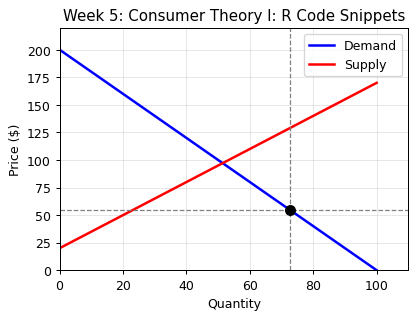

In [ ]:
# Supply & demand plot — output pre-rendered for viewer testing
P_range <- seq(0, 100, by = 0.5)
Qd <- 200 - 2 * P_range
Qs <- 20 + 1.5 * P_range
plot(Qd, P_range, type='l', col='blue', lwd=2,
     xlab='Quantity', ylab='Price', main='Supply & Demand')
lines(Qs, P_range, col='red', lwd=2)
legend('topright', c('Demand','Supply'), col=c('blue','red'), lty=1)

## Viewer Test: Empty Cell

The cell below is intentionally empty — the viewer should skip it gracefully.

## Common Patterns

**Cobb-Douglas Demand**

```r
x1 <- alpha * m / p1
x2 <- (1 - alpha) * m / p2
```

**Perfect Substitutes**

```r
if (a/p1 > b/p2) x1 <- m/p1 else x2 <- m/p2
```

**Perfect Complements**

```r
x1 <- m / (p1 + p2 * a/b)
x2 <- (a/b) * x1
```

## Debugging Tips

| Error | Cause | Fix |
|-------|-------|-----|
| `Negative demands` | Numerical solver went outside feasible region | Add lower bounds: lb = c(0.001, 0.001) |
| `MRS ≠ price ratio at 'optimum'` | Corner solution (perfect substitutes) or calculation error | Check if one demand is zero; verify FOCs |
| `Budget not exhausted` | Non-monotonic preferences or numerical issues | Check utility function satisfies monotonicity |